In [376]:
import numpy as np
import matplotlib.pyplot as plt
from nav_msgs.msg import OccupancyGrid
from geometry_msgs.msg import Pose
import random
import math
from scipy.spatial import cKDTree
from skimage.draw import line

In [377]:
class Node:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.parent = None
        self.children = []
        self.cost = 0.0

    def add_child(self, x, y):
        child_node = Node(x, y)
        child_node.parent = self
        self.children.append(child_node)
        return child_node
    
    def __repr__(self):
        parent_str = f"({self.parent.x:.2f}, {self.parent.y:.2f})" if self.parent else "None"
        return f"Node(x={self.x:.2f}, y={self.y:.2f}, parent={parent_str}, children={len(self.children)})"
        

In [419]:
# Create the grid
grid = OccupancyGrid()
grid.info.width = 100
grid.info.height = 100
grid.info.resolution = 0.1
grid.info.origin = Pose()

data_np = np.zeros((grid.info.height, grid.info.width), dtype=np.int8)

data_np[75:80, 15:55] = 100
data_np[15:70, 15:20] = 100
data_np[15:20, 15:65] = 100
data_np[25:55, 75:80] = 100
data_np[60:65, 35:80] = 100
data_np[30:55, 35:40] = 100


# Flatten to 1D list for OccupancyGrid
grid.data = data_np.flatten().tolist()

In [460]:
class RRT_v2():
    def __init__(self, node, occupancy_grid, num_iterations, goal):
        self.root_node = node
        self.nodes = [self.root_node]
        self.og = occupancy_grid

        self.num_iterations = num_iterations
        self.tree_size = 1
        self.step_size = 0.30
        self.sample_goal_bias = 0.05
        self.goal = goal
        self.r_goal = 0.15
        self.best_cost = float('inf')
        self.best_node = None

        self.node_coords = [(node.x, node.y)]
        self.kd_tree = cKDTree(self.node_coords)

        self.gamma_rrt = 2.0
        self.d = 2 # dimensions for calculating radius

        self.count = 0


    def add_node(self, new_node):
        self.nodes.append(new_node)
        self.node_coords.append((new_node.x, new_node.y))
        self.tree_size += 1

        if self.tree_size % 50 == 0:
            self.kd_tree = cKDTree(self.node_coords)

    # primitive procedures from https://arxiv.org/pdf/1105.1186

    def sample_free(self):
        if random.random() < self.sample_goal_bias:
            return self.goal

        x = self.og.info.origin.position.x + random.uniform(0, self.og.info.width * self.og.info.resolution)
        y = self.og.info.origin.position.y + random.uniform(0, self.og.info.height * self.og.info.resolution)
        x_rand = (x, y)
        return x_rand
    
    def informed_sample(self, x_start, x_goal, c_best):
        x0, y0 = x_start
        x1, y1 = x_goal

        c_min = math.hypot(x1 - x0, y1 - y0)

        if not math.isfinite(self.best_cost) or c_best <= c_min:
            return self.sample_free()
        
        self.count += 1
        
        ellipse_center_x = 0.5 * (x0 + x1)
        ellipse_center_y = 0.5 * (y0 + y1)

        theta = math.atan2(y1 - y0, x1 - x0)

        r1 = self.best_cost / 2.0
        r2 = math.sqrt(self.best_cost**2 - c_min**2) / 2.0

            # --- Sample uniformly from the unit disk
        u = random.random()
        v = random.random()
        r = math.sqrt(u)
        angle = 2.0 * math.pi * v
        x_ball = r * math.cos(angle)
        y_ball = r * math.sin(angle)

        # --- Scale from unit circle → ellipse coordinates
        x_ell = r1 * x_ball
        y_ell = r2 * y_ball

        # --- Rotate ellipse sample into world frame
        x_rot = x_ell * math.cos(theta) - y_ell * math.sin(theta)
        y_rot = x_ell * math.sin(theta) + y_ell * math.cos(theta)

        # --- Translate to ellipse center
        x_rand = x_rot + ellipse_center_x
        y_rand = y_rot + ellipse_center_y

        return (x_rand, y_rand)
    
    def nearest(self, x_rand):
        distance, idx = self.kd_tree.query(x_rand)
        return self.nodes[idx]
    
    def near(self, x_new, radius):
        indices = self.kd_tree.query_ball_point(x_new, radius)
        nodes = []
        for i in indices:
            nodes.append(self.nodes[i])
        return nodes
    
    def steer(self, x_nearest, x_rand):
        theta = math.atan2(x_rand[1] - x_nearest.y, x_rand[0] - x_nearest.x)
        x_new = x_nearest.x + self.step_size * math.cos(theta)
        y_new = x_nearest.y + self.step_size * math.sin(theta)
        return (x_new, y_new)
    
    def collision_free(self, x_nearest, x_new):
        x0, y0 = self.world_to_grid(x_nearest)
        x1, y1 = self.world_to_grid(x_new)

        row, col = line(y0, x0, y1, x1)

        for gy, gx in zip(row, col):
            if gx < 0 or gy < 0 or gx >= self.og.info.width or gy >= self.og.info.height:
                return False

            index = gy * self.og.info.width + gx
            value = self.og.data[index]
            if value == 100:
                return False

        return True
    
    def line_cost(self, p1, p2):
        return math.hypot(p1[0] - p2[0], p1[1] - p2[1])
    
    def in_goal_region(self, x):
        return math.hypot(x[0] - self.goal[0], x[1] - self.goal[1]) < self.r_goal
            
    # helper

    def world_to_grid(self, point):
        x, y = point
        gx = int((x - self.og.info.origin.position.x) / self.og.info.resolution)
        gy = int((y - self.og.info.origin.position.y) / self.og.info.resolution)
        return gx, gy
    
    def get_radius(self):
        d = self.d
        gamma_rrt = self.gamma_rrt
        n = max(self.tree_size, 2)

        radius = min(gamma_rrt * (math.log(n) / n) ** (1 / d), self.step_size)
        return radius
    
    def plot_tree(self):
        xs = []
        ys = []
        gx = self.goal[0]
        gy = self.goal[1]

        for node in self.nodes:
            xs.append(node.x)
            ys.append(node.y)
            
            for child in node.children:
                plt.plot([node.x, child.x], [node.y, child.y], 'b-', linewidth=0.8)


        plt.scatter(xs, ys, s=10, c='red')
        plt.scatter(gx, gy, s=20, c='green', marker='X')


        if self.best_node:
             path = self.extract_best_path()
             px, py = zip(*path)
             plt.plot(px, py, 'y-', linewidth=1.5, label="best path")

    def extract_best_path(self):
        if self.best_node is None:
            print("no path found")
            return []
        
        path = []
        current = self.best_node
        while current is not None:
            path.append((current.x, current.y))
            current = current.parent

        path.reverse()
        return path
        
    
    # the main algorithm

    def run_RRT(self):
        while self.tree_size < self.num_iterations:
            x_rand = self.informed_sample((0.0, 0.0), (self.goal[0], self.goal[1]), self.best_cost)
            x_nearest = self.nearest(x_rand)
            x_new = self.steer(x_nearest, x_rand)

            if self.collision_free((x_nearest.x, x_nearest.y), x_new):
                x_near = self.near(x_new, self.get_radius())
                x_new_node = Node(x_new[0], x_new[1])
                x_new_node.parent = x_nearest
                x_new_node.cost = x_nearest.cost + self.line_cost(x_new, (x_nearest.x, x_nearest.y))

                best_parent = x_nearest
                best_cost = x_new_node.cost

                for node in x_near:
                    if self.collision_free((node.x, node.y), x_new):
                        cost = node.cost + self.line_cost((node.x, node.y), x_new)
                        if cost < best_cost:
                            best_parent = node
                            best_cost = cost

                x_new_node.parent = best_parent
                x_new_node.cost = best_cost
                best_parent.children.append(x_new_node)
                self.add_node(x_new_node)

                for node in x_near:
                    if node == best_parent:
                        continue

                    if self.collision_free((x_new_node.x, x_new_node.y), (node.x, node.y)):
                        cost = x_new_node.cost + self.line_cost((x_new_node.x, x_new_node.y), (node.x, node.y))
                        if cost < node.cost:
                            if node.parent:
                                node.parent.children.remove(node)
                            node.parent = x_new_node 
                            node.cost = cost
                            x_new_node.children.append(node)

                if self.in_goal_region(x_new):
                    if x_new_node.cost < self.best_cost:
                        self.best_cost = x_new_node.cost
                        self.best_node = x_new_node
                        print(f"Found new best node, cost = {self.best_cost:.3f}")

        print("finished RRT")          
        return
    

Found new best node, cost = 9.300
Found new best node, cost = 9.181
finished RRT


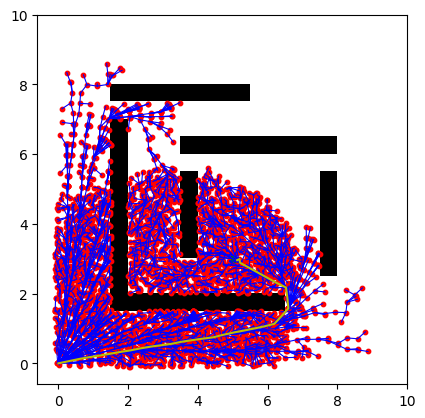

In [466]:
A = Node(0, 0)

tree = RRT_v2(A, grid, 5000, (5.0, 3.0))

tree.run_RRT()
plt.imshow(data_np, cmap='gray_r', origin='lower',
           extent=[0, grid.info.width * grid.info.resolution,
                   0, grid.info.height * grid.info.resolution])
tree.plot_tree()
plt.show()

